In [12]:
# ============================================================================
#  - OPTIMIZACIÓN
# ============================================================================

print("\n" + "="*60)
print("OPTIMIZACIÓN DE HIPERPARÁMETROS")
print("="*60)

# Optimizar Random Forest
print("\n🔧 Optimizando Random Forest...")
param_dist_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist_rf, n_iter=10, cv=5, scoring='f1',
    random_state=42, n_jobs=-1
)
random_search_rf.fit(X_train_scaled, y_train)

print(f"   Mejores parámetros: {random_search_rf.best_params_}")
print(f"   Mejor F1-Score (CV): {random_search_rf.best_score_:.4f}")

# Optimizar Gradient Boosting
print("\n🔧 Optimizando Gradient Boosting...")
param_dist_gb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

random_search_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_dist_gb, n_iter=9, cv=5, scoring='f1',
    random_state=42, n_jobs=-1
)
random_search_gb.fit(X_train_scaled, y_train)

print(f"   Mejores parámetros: {random_search_gb.best_params_}")
print(f"   Mejor F1-Score (CV): {random_search_gb.best_score_:.4f}")

# Evaluar modelos optimizados
rf_opt = random_search_rf.best_estimator_
gb_opt = random_search_gb.best_estimator_

y_pred_rf_opt = rf_opt.predict(X_test_scaled)
y_pred_gb_opt = gb_opt.predict(X_test_scaled)

print("\n📊 RENDIMIENTO EN TEST:")
print(f"   Random Forest Optimizado - F1: {f1_score(y_test, y_pred_rf_opt):.4f}")
print(f"   Gradient Boosting Optimizado - F1: {f1_score(y_test, y_pred_gb_opt):.4f}")

# Guardar modelos optimizados
joblib.dump(rf_opt, f'{BASE}/models/trained_models/RandomForest_optimized.pkl')
joblib.dump(gb_opt, f'{BASE}/models/trained_models/GradientBoosting_optimized.pkl')
print("\n✅ Modelos optimizados guardados")


OPTIMIZACIÓN DE HIPERPARÁMETROS

🔧 Optimizando Random Forest...
   Mejores parámetros: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10}
   Mejor F1-Score (CV): 0.9832

🔧 Optimizando Gradient Boosting...
   Mejores parámetros: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2}
   Mejor F1-Score (CV): 0.9820

📊 RENDIMIENTO EN TEST:
   Random Forest Optimizado - F1: 0.9772
   Gradient Boosting Optimizado - F1: 0.9772

✅ Modelos optimizados guardados



COMPARACIÓN ORIGINAL VS OPTIMIZADO
           Modelo  F1_Original  F1_Optimizado  Mejora
    Random Forest       0.9753         0.9772  0.0019
Gradient Boosting       0.9734         0.9772  0.0038


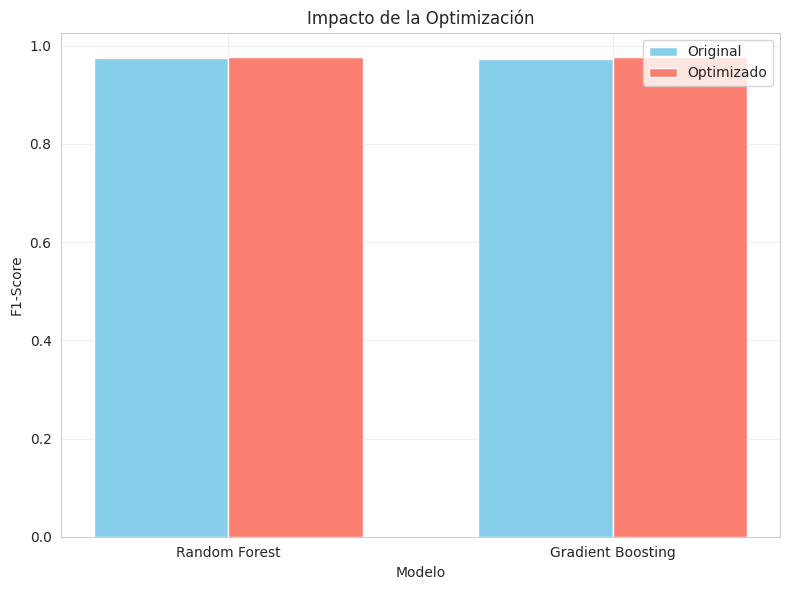


✅ Gráfico guardado en /content/drive/MyDrive/twitter_project/results/plots/


In [13]:
# ============================================================================
# COMPARACIÓN ORIGINAL VS OPTIMIZADO
# ============================================================================

print("\n" + "="*60)
print("COMPARACIÓN ORIGINAL VS OPTIMIZADO")
print("="*60)

# Obtener F1 de modelos originales
rf_original = trained_models['Random Forest']
gb_original = trained_models['Gradient Boosting']

y_pred_rf_orig = rf_original.predict(X_test_scaled)
y_pred_gb_orig = gb_original.predict(X_test_scaled)

comparacion = pd.DataFrame({
    'Modelo': ['Random Forest', 'Gradient Boosting'],
    'F1_Original': [f1_score(y_test, y_pred_rf_orig), f1_score(y_test, y_pred_gb_orig)],
    'F1_Optimizado': [f1_score(y_test, y_pred_rf_opt), f1_score(y_test, y_pred_gb_opt)],
    'Mejora': [f1_score(y_test, y_pred_rf_opt) - f1_score(y_test, y_pred_rf_orig),
               f1_score(y_test, y_pred_gb_opt) - f1_score(y_test, y_pred_gb_orig)]
})

print(comparacion.round(4).to_string(index=False))

# Gráfico de mejora
plt.figure(figsize=(8, 6))
x = np.arange(len(comparacion['Modelo']))
width = 0.35

plt.bar(x - width/2, comparacion['F1_Original'], width, label='Original', color='skyblue')
plt.bar(x + width/2, comparacion['F1_Optimizado'], width, label='Optimizado', color='salmon')

plt.xlabel('Modelo')
plt.ylabel('F1-Score')
plt.title('Impacto de la Optimización')
plt.xticks(x, comparacion['Modelo'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE}/results/plots/impacto_optimizacion.png')
plt.show()

print(f"\n✅ Gráfico guardado en {BASE}/results/plots/")